# Full Process Lens For This Project

Use this section every time you start a project so you practice the same end-to-end workflow, not just isolated coding tasks.

## 1) Data Transformation and Processing (What and Why)

Raw data is rarely model-ready. Your first job is to transform data into a reliable, learnable format.

What to do in every project:
- Identify data types and expected schema.
- Handle missing values, duplicates, and inconsistent formats.
- Convert features into model-usable representations (encoding, scaling, tokenization, chunking, etc.).
- Keep transformations reproducible so train and inference use the same logic.
- Document assumptions and risks introduced by preprocessing choices.

Why this matters:
- Better preprocessing usually improves results more than switching algorithms.
- Poor preprocessing creates hidden errors that look like model failure.

## 2) Evaluating and Improving Models (What and Why)

Evaluation is not the last step. It is the loop that drives improvement.

What to do in every project:
- Start with a baseline and compare against it.
- Choose metrics tied to the real goal (not just convenience metrics).
- Inspect errors by slice (segments, classes, edge cases).
- Tune thresholds, features, prompts, retrieval settings, or hyperparameters based on evidence.
- Re-evaluate after each change and keep track of what improved and what regressed.

Why this matters:
- A model can appear good overall but fail on important cases.
- Iterative evaluation is how projects become production-ready, not just demo-ready.

## 3) Project Reflection Checklist

Before marking this project complete, confirm:
- I can explain how data was transformed and why.
- I can explain which metrics I chose and why.
- I can show at least one improvement cycle from evaluation findings.
- I can describe current limitations and next improvements.

# Week 3 — NumPy Deep Dive
> **Phase 0 | Foundation** — The math engine under every ML library.

---

## Beginner Start Here

**NumPy** (Numerical Python) is the foundation of ALL numeric computing in Python. pandas, scikit-learn, PyTorch, TensorFlow — they all store your data internally as NumPy arrays. If you understand arrays, you understand how data flows through ML models.

### What You Will Learn
- What an ndarray is (N-dimensional array)
- How to create arrays: from lists, zeros, ones, random
- Array shapes and the meaning of dimensions
- Indexing and slicing arrays
- Broadcasting — doing math between arrays of different sizes
- Vectorized operations (fast math without loops)
- Dot product — the math behind neural networks
- Useful statistics: mean, std, var, min, max
- Reshape, transpose — the operations you'll do constantly in ML

### Key Terms
| Term | Plain English |
|------|---------------|
| **ndarray** | NumPy's core data structure — an N-dimensional array of numbers |
| **shape** | A tuple describing the array's dimensions e.g. (100, 5) means 100 rows, 5 columns |
| **dtype** | The numeric type of values in the array: float32, float64, int32, etc. |
| **axis** | A dimension of the array. axis=0 means 'down the rows', axis=1 means 'across columns' |
| **Broadcast** | NumPy's ability to apply operations between arrays of different shapes automatically |
| **Vectorized** | Operating on all elements at once instead of one at a time (much faster than loops) |
| **Dot product** | A matrix multiplication operation — the core math of neural networks |
| **Transpose** | Flip a matrix: rows become columns, columns become rows |

In [1]:
# ── First run check + imports ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

print(f"✅ NumPy {np.__version__} loaded. Week 3 notebook ready.")

✅ NumPy 2.0.2 loaded. Week 3 notebook ready.


---

## Section 1: Creating Arrays

A NumPy array is like a Python list, but:
- All elements are the **same type** (usually float or int)
- Math operations work on ALL elements at once (vectorized)
- It uses much less memory
- ML libraries expect arrays, not lists

```python
# Python list (slow for math):
prices = [10.5, 20.0, 15.3]
doubled = [p * 2 for p in prices]  # need a loop

# NumPy array (fast for math):
prices = np.array([10.5, 20.0, 15.3])
doubled = prices * 2               # applies to ALL elements instantly!
```

In [2]:
# ── Creating Arrays ───────────────────────────────────────────────────────────

# From a Python list
a = np.array([1, 2, 3, 4, 5])
print(f"From list:    {a}  shape={a.shape}  dtype={a.dtype}")

# 2D array (matrix)
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])
print(f"2D array shape: {matrix.shape}  ← (2 rows, 3 columns)")
print(matrix)

# Special arrays
print(f"\nnp.zeros((3,4)):")
print(np.zeros((3, 4)))

print(f"\nnp.ones((2,3)):")
print(np.ones((2, 3)))

print(f"\nnp.eye(3)  (identity matrix):")
print(np.eye(3))

# Range arrays
print(f"\nnp.arange(0, 10, 2):  {np.arange(0, 10, 2)}")  # like range()
print(f"np.linspace(0, 1, 5): {np.linspace(0, 1, 5)}")  # 5 evenly spaced points

# Random arrays
np.random.seed(42)
rand_arr = np.random.randn(3, 4)  # standard normal distribution
print(f"\nnp.random.randn(3,4) — shape {rand_arr.shape}:")
print(rand_arr.round(3))

From list:    [1 2 3 4 5]  shape=(5,)  dtype=int64
2D array shape: (2, 3)  ← (2 rows, 3 columns)
[[1 2 3]
 [4 5 6]]

np.zeros((3,4)):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

np.ones((2,3)):
[[1. 1. 1.]
 [1. 1. 1.]]

np.eye(3)  (identity matrix):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

np.arange(0, 10, 2):  [0 2 4 6 8]
np.linspace(0, 1, 5): [0.   0.25 0.5  0.75 1.  ]

np.random.randn(3,4) — shape (3, 4):
[[ 0.497 -0.138  0.648  1.523]
 [-0.234 -0.234  1.579  0.767]
 [-0.469  0.543 -0.463 -0.466]]


## Pre-Training Learning Checkpoint (Before Visualization or Modeling)

Before continuing, explain how array-level preparation affects reliable modeling.

Use Phase 0 references:
- guides/phase0/GUIDE_Week2_PandasDeep.md
- guides/phase0/GUIDE_Week3_NumPyDeep.md
- guides/phase0/GUIDE_Week4_Visualization.md

Reflection prompts:
1. What shape/type checks are required before training?
2. Which normalization or scaling decisions are needed and why?
3. How will you catch preparation mistakes early?

Done criteria:
- You can describe a repeatable array-prep checklist.
- You can justify readiness before model-oriented steps.

---

## Section 2: Shape and Dimensions

**Shape** is the most important property of any array. It tells you exactly how many elements there are in each dimension.

```
1D array — shape (5,)        →  [1, 2, 3, 4, 5]
2D array — shape (3, 4)      →  3 rows, 4 columns  (like a table)
3D array — shape (2, 3, 4)   →  2 "blocks" of (3 rows × 4 cols)  (like a stack of tables)
```

**In ML:**
- Your dataset X has shape `(n_samples, n_features)` — e.g., (1000, 12)
- Your labels y have shape `(n_samples,)` — e.g., (1000,)
- A batch in deep learning: `(batch_size, sequence_length, embedding_dim)` — 3D
- An image: `(height, width, channels)` — 3D
- A batch of images: `(batch_size, height, width, channels)` — 4D

In [3]:
# ── Shape, ndim, size ─────────────────────────────────────────────────────────

X = np.random.randn(100, 5)   # 100 samples, 5 features
y = np.random.randint(0, 2, 100)  # 100 binary labels

print("Feature matrix X:")
print(f"  shape:  {X.shape}   ← {X.shape[0]} samples, {X.shape[1]} features")
print(f"  ndim:   {X.ndim}    ← number of dimensions")
print(f"  size:   {X.size}   ← total number of elements")
print(f"  dtype:  {X.dtype}")

print(f"\nLabel vector y:")
print(f"  shape:  {y.shape}   ← 100 labels, 1D")

# Reshape: change shape without changing data
flat = np.arange(12)  # [0, 1, 2, ..., 11]
print(f"\nOriginal: {flat}  shape={flat.shape}")

reshaped_3x4 = flat.reshape(3, 4)
print(f"\nReshape to (3,4):")
print(reshaped_3x4)

reshaped_2x2x3 = flat.reshape(2, 2, 3)
print(f"\nReshape to (2,2,3):")
print(reshaped_2x2x3)

# -1 means 'figure it out' — very common in ML code
col_vector = flat.reshape(-1, 1)  # (12, 1) — a column vector
row_vector = flat.reshape(1, -1)  # (1, 12) — a row vector
print(f"\nreshape(-1,1): {col_vector.shape}  ← column vector")
print(f"reshape(1,-1): {row_vector.shape}  ← row vector")

Feature matrix X:
  shape:  (100, 5)   ← 100 samples, 5 features
  ndim:   2    ← number of dimensions
  size:   500   ← total number of elements
  dtype:  float64

Label vector y:
  shape:  (100,)   ← 100 labels, 1D

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]  shape=(12,)

Reshape to (3,4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Reshape to (2,2,3):
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]

reshape(-1,1): (12, 1)  ← column vector
reshape(1,-1): (1, 12)  ← row vector


In [19]:
# ── YOUR TURN: Shapes ─────────────────────────────────────────────────────────
# Create the following arrays and print their shapes:
# 1. A 50x3 array of zeros (50 samples, 3 features)
# 2. A 1D array from 0 to 19 (use np.arange)
# 3. Reshape the previous array to (4, 5)
# 4. What is the total size (number of elements) of a (3, 4, 5) array?

new_array_1 = np.zeros((50, 3))
print(f"1. Zeros array shape: {new_array_1.shape}")

new_array_2=np.arange(20)
print(f"2. 1D array shape: {new_array_2.shape}")
array_2_reshaped = new_array_2.reshape(4,5)
print(f"3. Reshaped array shape: {array_2_reshaped.shape}")

new_array_3=np.zeros((3,4,5))
print(f"4. Size of (3,4,5) array: {new_array_3.size}")

1. Zeros array shape: (50, 3)
2. 1D array shape: (20,)
3. Reshaped array shape: (4, 5)
4. Size of (3,4,5) array: 60


---

## Section 3: Indexing and Slicing

Same idea as Python lists but extended to multiple dimensions.

In [5]:
# ── Indexing and Slicing ─────────────────────────────────────────────────────

arr = np.array([[10, 20, 30, 40],
                [50, 60, 70, 80],
                [90, 100, 110, 120]])
print("Array:")
print(arr)
print(f"Shape: {arr.shape}  ← 3 rows, 4 columns")

# Single element: [row, column]
print(f"\narr[0, 0] = {arr[0, 0]}  ← top-left")
print(f"arr[1, 2] = {arr[1, 2]}  ← row 1, col 2")
print(f"arr[-1, -1] = {arr[-1, -1]}  ← bottom-right")

# Slicing rows and columns
print(f"\narr[0, :]   = {arr[0, :]}   ← entire first row")
print(f"arr[:, 0]   = {arr[:, 0]}   ← entire first column")
print(f"arr[1:, 2:] = ")
print(arr[1:, 2:])  # rows 1-end, cols 2-end

# Boolean indexing (same as pandas!)
print(f"\nElements > 60:")
print(arr[arr > 60])

# Fancy indexing — select specific rows
print(f"\nRows 0 and 2:")
print(arr[[0, 2], :])

Array:
[[ 10  20  30  40]
 [ 50  60  70  80]
 [ 90 100 110 120]]
Shape: (3, 4)  ← 3 rows, 4 columns

arr[0, 0] = 10  ← top-left
arr[1, 2] = 70  ← row 1, col 2
arr[-1, -1] = 120  ← bottom-right

arr[0, :]   = [10 20 30 40]   ← entire first row
arr[:, 0]   = [10 50 90]   ← entire first column
arr[1:, 2:] = 
[[ 70  80]
 [110 120]]

Elements > 60:
[ 70  80  90 100 110 120]

Rows 0 and 2:
[[ 10  20  30  40]
 [ 90 100 110 120]]


---

## Section 4: Vectorized Operations (Why NumPy is Fast)

The whole point of NumPy: **do math on entire arrays at once**, no loops.

Under the hood, NumPy operations run in optimized C code, which is 10-100x faster than Python loops.

In [6]:
# ── Vectorized Operations ─────────────────────────────────────────────────────

import time

prices = np.array([10.0, 25.0, 50.0, 75.0, 100.0])

# Element-wise math (applies to every element automatically)
print(f"prices:          {prices}")
print(f"prices * 2:      {prices * 2}")
print(f"prices + 5:      {prices + 5}")
print(f"prices ** 2:     {prices ** 2}")
print(f"np.sqrt(prices): {np.sqrt(prices).round(2)}")
print(f"np.log(prices):  {np.log(prices).round(3)}")

# SPEED COMPARISON: NumPy vs Python loop
big = np.random.randn(1_000_000)

start = time.time()
_ = [x**2 for x in big]  # Python loop
loop_time = time.time() - start

start = time.time()
_ = big ** 2              # NumPy vectorized
numpy_time = time.time() - start

print(f"\nOn 1,000,000 elements:")
print(f"  Python loop:      {loop_time:.3f}s")
print(f"  NumPy vectorized: {numpy_time:.4f}s")
print(f"  Speedup: ~{loop_time/numpy_time:.0f}x faster with NumPy")

prices:          [ 10.  25.  50.  75. 100.]
prices * 2:      [ 20.  50. 100. 150. 200.]
prices + 5:      [ 15.  30.  55.  80. 105.]
prices ** 2:     [  100.   625.  2500.  5625. 10000.]
np.sqrt(prices): [ 3.16  5.    7.07  8.66 10.  ]
np.log(prices):  [2.303 3.219 3.912 4.317 4.605]

On 1,000,000 elements:
  Python loop:      0.082s
  NumPy vectorized: 0.0110s
  Speedup: ~7x faster with NumPy


In [7]:
# ── Broadcasting ──────────────────────────────────────────────────────────────
# NumPy can do math between arrays of DIFFERENT shapes by 'stretching' the smaller one.
# This comes up constantly in ML (e.g., subtracting the mean from each feature column).

# Example: normalize a dataset (subtract mean, divide by std) — feature scaling
X = np.array([[1, 200, 0.5],
              [2, 150, 0.8],
              [3, 180, 0.3],
              [4, 220, 0.9]])
print("Raw X:")
print(X)

# Per-column stats
means = X.mean(axis=0)   # axis=0 = down the rows (compute one value per column)
stds  = X.std(axis=0)
print(f"\nColumn means: {means}")
print(f"Column stds:  {stds.round(3)}")

# Normalize: (X - mean) / std   — broadcasts means and stds across all rows automatically
X_normalized = (X - means) / stds
print(f"\nNormalized X:")
print(X_normalized.round(3))
print(f"\nVerify — means should be ~0: {X_normalized.mean(axis=0).round(10)}")
print(f"Verify — stds should be ~1:  {X_normalized.std(axis=0).round(3)}")

Raw X:
[[  1.  200.    0.5]
 [  2.  150.    0.8]
 [  3.  180.    0.3]
 [  4.  220.    0.9]]

Column means: [  2.5   187.5     0.625]
Column stds:  [ 1.118 25.86   0.238]

Normalized X:
[[-1.342  0.483 -0.524]
 [-0.447 -1.45   0.734]
 [ 0.447 -0.29  -1.363]
 [ 1.342  1.257  1.153]]

Verify — means should be ~0: [ 0. -0.  0.]
Verify — stds should be ~1:  [1. 1. 1.]


---

## Section 5: Statistics with NumPy

The `axis` parameter is key — it controls which direction you collapse:
- `axis=0` → collapse **down** (one result per column)
- `axis=1` → collapse **across** (one result per row)
- `axis=None` → collapse everything into a single number

In [8]:
# ── Statistics and the Axis Parameter ────────────────────────────────────────

# Imagine this is our feature matrix: 5 samples, 3 features
data = np.array([
    [1.0, 50.0, 0.2],
    [2.0, 80.0, 0.5],
    [3.0, 60.0, 0.8],
    [4.0, 90.0, 0.1],
    [5.0, 70.0, 0.9],
])
print(f"data shape: {data.shape} ← 5 samples, 3 features")
print(data)

print(f"\n--- axis=0: one stat PER COLUMN ---")
print(f"mean:    {data.mean(axis=0)}")   # average of each feature
print(f"std:     {data.std(axis=0).round(3)}")
print(f"min:     {data.min(axis=0)}")
print(f"max:     {data.max(axis=0)}")
print(f"sum:     {data.sum(axis=0)}")

print(f"\n--- axis=1: one stat PER ROW ---")
print(f"mean per sample:  {data.mean(axis=1).round(3)}")
print(f"sum per sample:   {data.sum(axis=1)}")

print(f"\n--- axis=None: single scalar ---")
print(f"overall mean:  {data.mean():.3f}")
print(f"overall sum:   {data.sum():.1f}")

data shape: (5, 3) ← 5 samples, 3 features
[[ 1.  50.   0.2]
 [ 2.  80.   0.5]
 [ 3.  60.   0.8]
 [ 4.  90.   0.1]
 [ 5.  70.   0.9]]

--- axis=0: one stat PER COLUMN ---
mean:    [ 3.  70.   0.5]
std:     [ 1.414 14.142  0.316]
min:     [ 1.  50.   0.1]
max:     [ 5.  90.   0.9]
sum:     [ 15.  350.    2.5]

--- axis=1: one stat PER ROW ---
mean per sample:  [17.067 27.5   21.267 31.367 25.3  ]
sum per sample:   [51.2 82.5 63.8 94.1 75.9]

--- axis=None: single scalar ---
overall mean:  24.500
overall sum:   367.5


In [20]:
# ── YOUR TURN: Statistics ─────────────────────────────────────────────────────
# Given this feature matrix:
X_test = np.array([
    [5, 100, 0.3],
    [3, 80, 0.7],
    [8, 120, 0.1],
    [2, 95, 0.9],
    [6, 110, 0.5],
])

# 1. Print the mean of each feature (column)
# 2. Print the standard deviation of each feature
# 3. Find the row (sample) with the highest sum across features
# 4. Normalize X_test: subtract per-column mean, divide by per-column std

means = X_test.mean(axis=0)
stds = X_test.std(axis=0)
print(f"1. Feature means: {means}")
print(f"2. Feature stds:  {stds.round(3)}")

row_sums = X_test.sum(axis=1)
max_row_index = np.argmax(row_sums)
print(f"3. Row with highest sum: index {max_row_index} (sum={row_sums[max_row_index]})")

# 4. Normalize X_test
X_test_normalized = (X_test - means) / stds
print(f"4. Normalized X_test:\n{X_test_normalized}")

1. Feature means: [  4.8 101.    0.5]
2. Feature stds:  [ 2.135 13.565  0.283]
3. Row with highest sum: index 2 (sum=128.1)
4. Normalized X_test:
[[ 0.09365858 -0.07372098 -0.70710678]
 [-0.84292723 -1.54814054  0.70710678]
 [ 1.4985373   1.40069858 -1.41421356]
 [-1.31122014 -0.44232587  1.41421356]
 [ 0.56195149  0.6634888   0.        ]]


---

## Section 6: Dot Product — The Math Behind ML

The **dot product** (matrix multiplication) is the operation at the heart of:
- Linear regression
- Logistic regression
- Every layer in a neural network
- Attention in transformers

**For vectors (1D):**  
$\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i$

**For matrices (2D):**  
$(A \cdot B)_{ij} = \sum_k A_{ik} B_{kj}$

**Shape rule:** `(m × k) @ (k × n) → (m × n)` — inner dimensions must match!

In [10]:
# ── Dot Product ───────────────────────────────────────────────────────────────

# --- 1D dot product (vector × vector) ---
features = np.array([1.0, 2.0, 3.0])    # one sample's feature values
weights  = np.array([0.5, -0.3, 0.8])   # learned model weights
bias     = 0.1

# In linear regression: prediction = features · weights + bias
prediction = np.dot(features, weights) + bias
# Same as: 1.0*0.5 + 2.0*(-0.3) + 3.0*0.8 + 0.1
print(f"Features:   {features}")
print(f"Weights:    {weights}")
print(f"Dot product: {np.dot(features, weights):.2f}")
print(f"+ bias:      {prediction:.2f}  ← model prediction")

# --- 2D matrix multiply (batch of samples) ---
X = np.array([[1.0, 2.0, 3.0],
              [4.0, 5.0, 6.0],
              [7.0, 8.0, 9.0]])  # 3 samples, 3 features each

W = np.array([[0.5], [-0.3], [0.8]])   # (3 features, 1 output)

# Predict for ALL samples at once: (3×3) @ (3×1) → (3×1)
predictions = X @ W  # @ is the matrix multiply operator
print(f"\nBatch predictions (3 samples at once):")
print(f"X shape: {X.shape}, W shape: {W.shape}")
print(f"X @ W shape: {predictions.shape}")
print(predictions)

Features:   [1. 2. 3.]
Weights:    [ 0.5 -0.3  0.8]
Dot product: 2.30
+ bias:      2.40  ← model prediction

Batch predictions (3 samples at once):
X shape: (3, 3), W shape: (3, 1)
X @ W shape: (3, 1)
[[2.3]
 [5.3]
 [8.3]]


In [11]:
# ── Transpose ────────────────────────────────────────────────────────────────
# Transpose flips rows and columns. Used constantly to make shapes compatible for dot products.

A = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f"A shape: {A.shape}")
print(A)

A_T = A.T    # or A.transpose()
print(f"\nA.T shape: {A_T.shape}")
print(A_T)

# Common use: (X.T @ X) in the Normal Equation for linear regression
X = np.random.randn(10, 3)   # 10 samples, 3 features
print(f"\nX shape:     {X.shape}")
print(f"X.T shape:   {X.T.shape}")
print(f"X.T @ X:     {(X.T @ X).shape}  ← 3×3 matrix")

A shape: (2, 3)
[[1 2 3]
 [4 5 6]]

A.T shape: (3, 2)
[[1 4]
 [2 5]
 [3 6]]

X shape:     (10, 3)
X.T shape:   (3, 10)
X.T @ X:     (3, 3)  ← 3×3 matrix


---

## Section 7: Useful NumPy Operations for ML

In [12]:
# ── Operations You'll Use Constantly ─────────────────────────────────────────

# np.clip — clamp values to a range (e.g., probabilities to [0,1])
raw_probs = np.array([-0.1, 0.3, 0.7, 1.2, 0.5])
clipped = np.clip(raw_probs, 0.0, 1.0)
print(f"raw_probs: {raw_probs}")
print(f"clipped:   {clipped}")

# np.argmax / np.argmin — index of max/min (used for predictions in classification)
class_scores = np.array([0.1, 0.7, 0.05, 0.15])  # model output for 4 classes
predicted_class = np.argmax(class_scores)
print(f"\nClass scores: {class_scores}")
print(f"Predicted class (argmax): {predicted_class}  ← class with highest score")

# np.where — conditional element selection
scores = np.array([0.8, 0.3, 0.6, 0.4, 0.9])
binary_labels = np.where(scores > 0.5, 1, 0)  # threshold at 0.5
print(f"\nScores:  {scores}")
print(f"Labels:  {binary_labels}  ← 1 if score > 0.5, else 0")

# np.unique — unique values and their counts
labels = np.array([0, 1, 1, 0, 1, 0, 0, 1, 1, 0])
unique, counts = np.unique(labels, return_counts=True)
print(f"\nClass distribution: {dict(zip(unique, counts))}")

# np.concatenate — stack arrays (use axis=0 for rows, axis=1 for columns)
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])
print(f"\nnp.concatenate row-wise:")
print(np.concatenate([a, b], axis=0))  # stack vertically
print(f"\nnp.concatenate col-wise:")
print(np.concatenate([a, b], axis=1))  # stack horizontally

raw_probs: [-0.1  0.3  0.7  1.2  0.5]
clipped:   [0.  0.3 0.7 1.  0.5]

Class scores: [0.1  0.7  0.05 0.15]
Predicted class (argmax): 1  ← class with highest score

Scores:  [0.8 0.3 0.6 0.4 0.9]
Labels:  [1 0 1 0 1]  ← 1 if score > 0.5, else 0

Class distribution: {np.int64(0): np.int64(5), np.int64(1): np.int64(5)}

np.concatenate row-wise:
[[1 2]
 [3 4]
 [5 6]
 [7 8]]

np.concatenate col-wise:
[[1 2 5 6]
 [3 4 7 8]]


X shape: (50, 2)  ← 50 samples, [x_value, 1]
y shape: (50,)

Learned parameters:
  Slope:     2.884  (true: 3.0)
  Intercept: 2.129  (true: 2.0)
  RMSE: 1.817


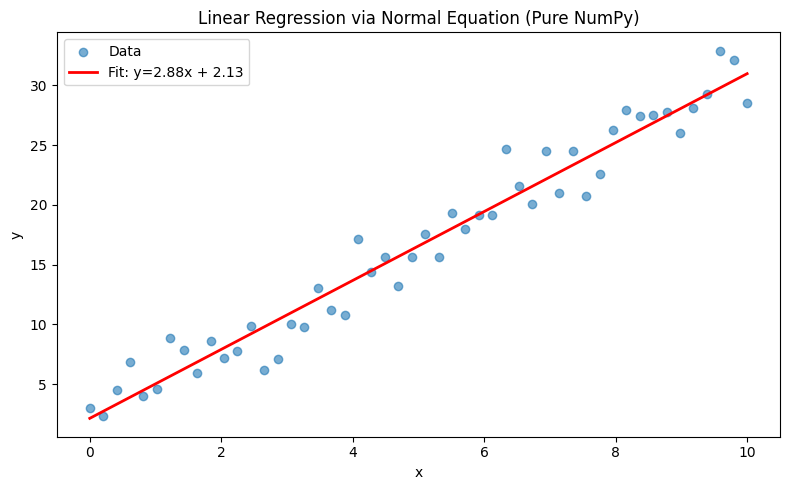


✅ You just implemented linear regression from scratch using NumPy!


In [13]:
# ── Putting It Together: Manual Linear Regression ────────────────────────────
# Let's implement a tiny linear regression using pure NumPy.
# This shows exactly how ML math maps to NumPy operations.

# Generate data: y ≈ 3x + 2 + noise
np.random.seed(42)
X_raw = np.linspace(0, 10, 50)
y = 3 * X_raw + 2 + np.random.randn(50) * 2

# Design matrix: add a column of 1s for the bias term
# X shape: (50,) → (50, 2) where col 0 = x values, col 1 = all 1s
X = np.column_stack([X_raw, np.ones(len(X_raw))])
print(f"X shape: {X.shape}  ← 50 samples, [x_value, 1]")
print(f"y shape: {y.shape}")

# Normal Equation: θ = (X^T X)^{-1} X^T y
# This finds the weights that minimize the sum of squared errors
theta = np.linalg.inv(X.T @ X) @ X.T @ y

slope, intercept = theta
print(f"\nLearned parameters:")
print(f"  Slope:     {slope:.3f}  (true: 3.0)")
print(f"  Intercept: {intercept:.3f}  (true: 2.0)")

# Predict
y_pred = X @ theta

# Compute RMSE: Root Mean Squared Error
rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(f"  RMSE: {rmse:.3f}")

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, label='Data')
plt.plot(X_raw, y_pred, 'r-', linewidth=2, label=f'Fit: y={slope:.2f}x + {intercept:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression via Normal Equation (Pure NumPy)')
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ You just implemented linear regression from scratch using NumPy!")

In [22]:
# ── YOUR TURN: Dot Product and Reshape ───────────────────────────────────────
# A neural network layer applies the operation: output = input @ weights + bias
#
# Given:
#   input  = [[1, 2, 3, 4]]          shape: (1, 4)  — 1 sample, 4 features
#   weights = [[0.1, 0.2],            shape: (4, 2)  — 4 inputs, 2 outputs
#               [0.3, -0.1],
#               [-0.2, 0.4],
#               [0.5, 0.1]]
#   bias    = [0.1, -0.2]            shape: (2,)
#
# 1. Compute output = input @ weights + bias
# 2. Print the shape of output
# 3. Apply a ReLU activation: relu(x) = max(0, x)  [use np.maximum(0, output)]

layer_input   = np.array([[1, 2, 3, 4]], dtype=float)
layer_weights = np.array([[0.1, 0.2], [0.3, -0.1], [-0.2, 0.4], [0.5, 0.1]])
layer_bias    = np.array([0.1, -0.2])

output = layer_input @ layer_weights + layer_bias
print(f"Output before activation: {output}  shape: {output.shape}")

relu_output = np.maximum(0, output)
print(f"Output after ReLU activation: {relu_output}  shape: {relu_output.shape}")

Output before activation: [[2.2 1.4]]  shape: (1, 2)
Output after ReLU activation: [[2.2 1.4]]  shape: (1, 2)


---

## Week 3 Reflection Questions

**Answer these (double-click to edit):**

1. What does `arr.shape` tell you? What does `(100, 5)` mean?

2. What is the difference between `axis=0` and `axis=1`?

3. Why is `arr * 2` faster than `[x * 2 for x in arr]`?

4. What shape rule must be satisfied for two matrices to be multiplied with `@`?

5. What does `.reshape(-1, 1)` do? When would you need it?

---

## Week 3 Checklist — Before You Move to Week 4

- [ ] I can create arrays from lists, zeros, ones, random, and arange/linspace
- [ ] I know what `.shape`, `.dtype`, `.ndim`, `.size` mean
- [ ] I can index and slice 1D and 2D arrays
- [ ] I understand that `axis=0` = down rows, `axis=1` = across columns
- [ ] I can normalize data using broadcasting
- [ ] I can compute and explain what the dot product does
- [ ] I can transpose a matrix with `.T`
- [ ] I completed the neural network layer exercise
- [ ] I implemented linear regression with the Normal Equation

**If you checked all boxes → go to STARTER_Week4_VisualizationDeep.ipynb**